In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import geopandas as gpd

from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from cmdstanpy import CmdStanModel
from tensorflow_probability.substrates import numpy as tfp
tfd = tfp.distributions

if not os.path.exists("./stan"):
    os.mkdir("./stan")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("/Users/tommasobaresi/Desktop/Bayesian-Statistics-Project/Bayesian-Statistics-Project/data/updated_data.csv")
df["ecec_diffusion"] = df["ecec_diffusion"].fillna(df["ecec_diffusion"].median())
df

,prov_name,fem_empl_rate,population,unempl_rate,part_rate,empl_rate,empl_growth,inact_rate,fem_edu_rate,male_edu_rate,...,GERD_total_intramural,public_coverage,private_coverage,other_percapita_public_expenditure,other_percapita_user_contrib,other_per_capita_expenditure,fem_maj_empl_rate,wr_men,ecec_diffusion,empl_gap
0,Oristano,43.5,151655,13.6,0.044271,51.4,0.000000,40.5,0.149833,0.101537,...,0.83,4.025045,5.813953,1186.043828,26.765653,1212.809481,4.873680,59.093522,34.5,0.74
1,Modena,65.9,701751,5.1,0.058595,71.0,4.487179,25.2,0.194783,0.156378,...,2.16,7.078254,5.112072,597.383405,23.532704,621.571503,4.259347,76.049129,97.9,0.87
2,Catanzaro,34.9,343673,13.6,0.042536,47.0,0.943396,45.6,0.198824,0.163084,...,0.59,1.335648,6.411113,171.707359,0.000000,171.707359,3.975738,59.382716,17.5,0.59
3,Rimini,57.9,338369,6.7,0.054481,65.2,0.000000,30.1,0.209848,0.165499,...,2.16,6.282562,3.984064,225.224487,0.444376,225.668863,4.708083,72.714210,77.8,0.80
4,Teramo,55.4,299646,6.3,0.051762,62.5,1.666667,33.3,0.197518,0.154127,...,1.14,4.961958,4.134965,126.776381,18.014720,144.791102,2.794672,69.606567,70.2,0.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,Salerno,35.2,1064493,14.5,0.044224,47.9,2.102102,44.0,0.188605,0.162715,...,1.33,4.167182,3.218220,110.896357,0.422907,111.319264,5.376815,60.616355,96.2,0.58
103,Savona,56.2,268038,5.1,0.050063,66.1,4.854369,30.4,0.175783,0.147137,...,1.62,5.428369,7.080481,359.453387,54.240736,413.694123,3.981380,75.956257,42.0,0.74
104,Crotone,26.6,163553,17.2,0.035260,36.9,-2.439024,55.5,0.156642,0.130076,...,0.59,1.237624,7.920792,255.460396,0.000000,255.460396,6.497325,47.298776,18.5,0.56
105,Ragusa,41.9,316142,9.9,0.047022,54.0,0.900901,40.0,0.152868,0.131528,...,0.92,1.637073,2.518574,19.897620,0.000000,19.897620,4.601973,65.762279,58.3,0.64


In [3]:
y = df["fem_empl_rate"].to_numpy()
y = y / 100
y_star = np.log(y / (1 - y))

selected_covariates = ["coverage", "per_capita_user_contribution", "ageing_index", "ecec_participation", "per_capita_public_expenditure", "service_empl_rate", "ecec_diffusion", "n_members_family", "avg_children_per_woman", "fem_house_rate"]
X = df[selected_covariates].to_numpy()
X_scaler = StandardScaler()
X_star = X_scaler.fit_transform(X)

offset = df["wr_men"].to_numpy()
offset = offset / 100
offset_star = np.log(offset / (1 - offset))

N = 107 # number of provinces
P = len(selected_covariates) # number of covariates
K = 3 # number of mixture components

In [4]:
mix_model = """
data {
  int<lower=1> N;          
  int<lower=1> P;          
  int<lower=1> K;          
  vector[N] y_star;             
  matrix[N, P] X_star;          
  vector[N] offset_star;        
}

parameters {
  simplex[K] pi;           
  vector[K] alpha;         
  matrix[K, P] beta;       
  real<lower=0> sigma;     
}

model {
  // Priors
  pi ~ dirichlet(rep_vector(1.0, K));   // Dirichlet(1,...,1)

  for (k in 1:K) {
    alpha[k] ~ normal(0, 5);
    for (j in 1:P) {
      beta[k, j] ~ normal(0, 5);
    }
  }

  sigma ~ normal(0, 1);   // half-normal(0,1)

  // Likelihood
  for (i in 1:N) {
    vector[K] lps;
    for (k in 1:K) {
      real mu_ik;
      mu_ik = alpha[k] + dot_product(row(X_star, i), beta[k]) + offset_star[i];
      lps[k] = log(pi[k]) + normal_lpdf(y_star[i] | mu_ik, sigma);
    }
    target += log_sum_exp(lps);
  }
}
"""

In [5]:
with open("mix_model.stan", "w") as f:
    f.write(mix_model)

In [6]:
data = {
    "N": int(N),
    "P": int(P),
    "K": int(K),
    "y_star": y_star.astype(float),
    "X_star": X_star.astype(float),
    "offset_star": offset_star.astype(float),
}


In [7]:
mix_stan = CmdStanModel(stan_file="mix_model.stan")

18:13:53 - cmdstanpy - INFO - compiling stan file /Users/tommasobaresi/Desktop/Bayesian-Statistics-Project/Bayesian-Statistics-Project/mixture_model/mix_model.stan to exe file /Users/tommasobaresi/Desktop/Bayesian-Statistics-Project/Bayesian-Statistics-Project/mixture_model/mix_model
18:13:58 - cmdstanpy - INFO - compiled model executable: /Users/tommasobaresi/Desktop/Bayesian-Statistics-Project/Bayesian-Statistics-Project/mixture_model/mix_model


In [8]:
fit = mix_stan.sample(
    data=data,
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    adapt_delta=0.9,
    seed=123
)


18:13:59 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]


chain 1:   5%|▌         | 100/2000 [00:03<01:04, 29.60it/s, (Warmup)]


chain 1:  10%|█         | 200/2000 [00:05<00:43, 41.10it/s, (Warmup)]


chain 1:  15%|█▌        | 300/2000 [00:06<00:35, 48.26it/s, (Warmup)]


chain 1:  20%|██        | 400/2000 [00:08<00:28, 55.50it/s, (Warmup)]


chain 1:  25%|██▌       | 500/2000 [00:09<00:25, 59.44it/s, (Warmup)]


chain 1:  30%|███       | 600/2000 [00:11<00:22, 63.25it/s, (Warmup)]


chain 1:  35%|███▌      | 700/2000 [00:12<00:19, 65.73it/s, (Warmup)]


chain 1:  40%|████      | 800/2000 [00:13<00:17, 67.01it/s, (Warmup)]


chain 1:  45%|████▌     | 900/2000 [00:15<00:16, 66.44it/s, (Warmup)]


chain 1:  50%|█████     | 1000/2000 [00:16<00:14, 67.98it/s, (Sampling)]





chain 1:  55%|█████▌    | 1100/2000 [00:17<00:12, 73.44it/s, (Sampling)]

chain 1:  60%|██████    | 1200/2000 [00:18<00:10, 78.87it/s, (Sampling)]


chain 1:


18:14:35 - cmdstanpy - INFO - CmdStan done processing.


In [9]:
fit_summary = fit.summary()
fit_summary.head()


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,41.784600,0.101797,4.338690,4.317390,34.243800,42.067400,48.266000,1826.67000,2902.24,32.418800,1.00058
pi[1],0.252464,0.297091,0.420880,0.012557,0.000718,0.010706,0.992239,7.17737,2000.00,0.127380,1.53072
pi[2],0.495502,0.343224,0.486217,0.723375,0.001101,0.492401,0.994956,6.09277,2000.00,0.108131,1.73300
pi[3],0.252034,0.297201,0.421032,0.011991,0.000598,0.009946,0.992639,7.21035,2000.00,0.127966,1.52799
alpha[1],-0.101688,0.069150,4.409260,3.052090,-7.597050,-0.786031,7.717930,4109.57000,2000.00,72.934500,1.51623


In [10]:
pi_samples = fit.stan_variable("pi")      # shape ~ (draws, K)
alpha_samples = fit.stan_variable("alpha")  # (draws, K)
beta_samples = fit.stan_variable("beta")    # (draws, K, P)
sigma_samples = fit.stan_variable("sigma")  # (draws,)

In [11]:
pi_samples.mean(axis=0)

array([0.25246357, 0.49550243, 0.252034  ])

In [12]:
pi_mean = pi_samples.mean(axis=0)          # (K,)
alpha_mean = alpha_samples.mean(axis=0)    # (K,)
beta_mean = beta_samples.mean(axis=0)      # (K, P)
sigma_mean = sigma_samples.mean()          # scalare

N = X_star.shape[0]
P = X_star.shape[1]
K = pi_mean.shape[0]

mu = np.zeros((N, K))

for k in range(K):
    mu[:, k] = alpha_mean[k] + X_star @ beta_mean[k] + offset_star

f = np.zeros((N, K))
for k in range(K):
    f[:, k] = norm.pdf(y_star, loc=mu[:, k], scale=sigma_mean)

numer = pi_mean * f          # broadcasting → shape (N, K)
denom = numer.sum(axis=1)    # (N,)
responsibilities = numer / denom[:, None]

cluster_assignment = np.argmax(responsibilities, axis=1)

<Axes: >

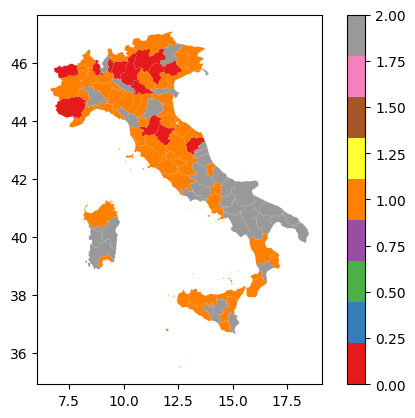

In [13]:
df["cluster"] = cluster_assignment

import geopandas as gpd
gdf = gpd.read_file("/Users/tommasobaresi/Desktop/Bayesian-Statistics-Project/Bayesian-Statistics-Project/data/updated_data.geojson")
gdf = gdf.merge(df[["prov_name", "cluster"]], on="prov_name", how="left")

gdf.plot(column="cluster", cmap="Set1", legend=True)
